# 🏦 Finora AI: Motor de Categorización Automática (RF-14)
Este Notebook contiene el desarrollo, entrenamiento y evaluación del motor de Inteligencia Artificial para la aplicación Finora. El objetivo principal es la implementación del requisito [RF-14] Categorización automática con IA, permitiendo que el sistema asigne categorías a transacciones bancarias a partir de su descriptor de texto (NLP).

## 🎯 Objetivos del Módulo
- Procesamiento de Lenguaje Natural (NLP): Limpieza y normalización de descriptores bancarios (ruidosos por naturaleza).

- Clasificación Híbrida: Implementación de una lógica de tres niveles (Diccionario -> Fuzzy Matching -> Modelo Machine Learning).

- Cálculo de Confianza: Generación de un score (0-100%) para validar la precisión de la categoría.

- Estrategia de Fallback: Implementación de la categoría "Otros" para predicciones con confianza < 50%.

## 🏗️ Arquitectura del Clasificador
Para maximizar la eficiencia y cumplir con el requisito de "Aprendizaje continuo", el sistema sigue este flujo:

1. Nivel de Reglas (Expert System): Coincidencias exactas basadas en el feedback histórico del usuario.

2. Nivel de Similitud (Fuzzy): Coincidencias parciales para variaciones menores en el nombre del comercio.

3. Nivel de Inferencia (ML Model): Clasificador estadístico (usando Scikit-Learn o Transformers) para descriptores nunca antes vistos.

## 🛠️ Fases del Notebook
1. Exploración y Limpieza de Datos: Análisis del dataset de transacciones y preprocesamiento de texto.

2. Ingeniería de Características: Vectorización de texto (TF-IDF o Embeddings).

3. Entrenamiento del Modelo: Comparativa de algoritmos de clasificación.

4. Evaluación: Análisis de métricas (Precision, Recall y F1-Score) y Matriz de Confusión.

5. Exportación: Persistencia del modelo para su despliegue en un entorno de producción (Docker + FastAPI).

In [11]:
# ==============================================================================
# CONFIGURACIÓN INICIAL Y CARGA DE LIBRERÍAS
# ==============================================================================

# Gestión de datos y matemáticas
import pandas as pd
import numpy as np

# Procesamiento de Texto y NLP
import re
import string
import joblib # Para exportar el modelo final

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización y avisos
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# ==============================================================================
# CONSTANTES DEL PROYECTO (Basadas en RF-14)
# ==============================================================================

CATEGORIES = [
    "Alimentación", "Transporte", "Vivienda", "Ocio", 
    "Salud", "Suscripciones", "Ingresos", "Otros"
]

CONFIDENCE_THRESHOLD = 0.50  # Fallback a "Otros" si confianza < 50%
RANDOM_STATE = 42            # Para que los resultados sean reproducibles

print(f"✅ Entorno listo. Categorías cargadas: {len(CATEGORIES)}")

✅ Entorno listo. Categorías cargadas: 8


# 📂 Fase 1: Creación del Dataset Sintético
Para entrenar nuestro modelo, necesitamos un conjunto de datos que asocie "Descriptores de transacciones" con sus "Categorías". En un entorno real, estos datos vendrían de la base de datos de Finora tras el feedback de los usuarios.

Para este desarrollo, generaremos un dataset sintético que cubra los casos más comunes en el contexto español (supermercados, gasolineras, nóminas, suscripciones, etc.). Cada entrada constará de:

- Descriptor: El texto ruidoso que aparece en el extracto bancario.

- Category: La etiqueta correcta (Target).

In [12]:
# ==============================================================================
# GENERACIÓN DE DATOS DE ENTRENAMIENTO (VERSIÓN MEJORADA)
# ==============================================================================
import random

def generate_synthetic_data():
    raw_data = {
        "Alimentación": [
            "MERCADONA MADRID", "MERCADONA BARCELONA", "MERCADONA 0234",
            "COMPRA MERCADONA", "SUPERMERCADO MERCADONA", "MERCAT MERCADONA",
            "CARREFOUR EXPRESS", "CARREFOUR MARKET", "CARREFOUR CITY",
            "SUPERMERCADO CARREFOUR", "CARREFOUR 0192",
            "LIDL SUPERMERCADOS", "LIDL TIENDA", "COMPRA LIDL",
            "DIA MARKET", "DIA SUPERMERCADO", "SUPERDÍA",
            "ALCAMPO SA", "ALCAMPO HIPER", "COMPRA ALCAMPO",
            "EROSKI CONSUMO", "EROSKI CENTER", "EROSKI CITY",
            "FRUTERIA PEPE", "FRUTERIA LA ESQUINA", "FRUTERIA CENTRAL",
            "BAZAR ALIMENTOS", "TIENDA ALIMENTACION",
            "CORTE INGLES SUPER", "EL CORTE INGLES ALIMENTACION",
            "CONSUM SUPERMERCADO", "CONSUM TIENDA",
            "BM SUPERMERCADOS", "AHORRAMAS SUPER",
            "SIMPLY MARKET", "SIMPLY FRESH",
            "ALDI SUPERMERCADOS", "ALDI 0345",
            "FROIZ SUPERMERCADO", "GADIS SUPER",
            "PAGUE MENOS", "PAGUE MENOS SUPERMERCADO", "PAGUE MENOS ALIMENTACION",
            "SUPERCOR MADRID",
            "CARNICERIA SAN JOSE", "PESCADERIA EL MAR",
            "PANADERIA LA ESPIGA", "OBRADOR CENTRAL",
            "COLMADO MARTINEZ", "ULTRAMARINOS",
            "FRUTERIA PEPE MADRID", "FRUTERIA JUAN",
        ],
        "Transporte": [
            "REPSOL ESTACION", "REPSOL GAS MADRID", "REPSOL 2341",
            "GASOLINERA CEPSA", "CEPSA ESTACION", "CEPSA 1234",
            "BP OIL SPAIN", "BP STATION", "BP GASOLINERA",
            "RENFE MADRID", "RENFE CERCANIAS", "RENFE AVE", "RENFE BILLETE",
            "UBER TRIP", "UBER PAYMENT", "UBER BV",
            "CABIFY SPAIN", "CABIFY VIAJE",
            "METRO MADRID", "METRO BARCELONA", "METRO BILBAO",
            "PARKING CENTRO", "PARKING EL CORTE", "PARKING VINCI",
            "PARKING CIUDAD", "PARKING AEROPUERTO", "PARKING HOSPITAL",
            "PEAJE AP-7", "PEAJE A-6", "AUTOPISTAS TOLL",
            "EMT MADRID", "EMT AUTOBUS", "EMT BILLETE",
            "TMB BARCELONA", "AUTOBUSES URBANOS",
            "BLABLACAR", "ALSA AUTOCARES",
            "VUELING BILLETE", "IBERIA BILLETE", "RYANAIR FLIGHT",
            "AENA AEROPUERTO", "EASYJET TICKET",
            "RODALIES BARCELONA", "FGV METRO VALENCIA",
            "TAXI MADRID", "TAXI BCNA", "MYTAXI TRIP",
            "GALP GASOLINERA", "GALP STATION",
            "SHELL GASOL", "TOTAL ENERGIES GASOLINERA",
        ],
        "Vivienda": [
            "IBERDROLA LUZ", "IBERDROLA RECIBO", "FACTURA IBERDROLA",
            "ENDESA RECIBO", "ENDESA ELECTRICIDAD", "ENDESA SA",
            "CANAL ISABEL II", "CANAL AGUA", "AGUAS MUNICIPALES",
            "COMUNIDAD PROPIETARIOS", "GASTOS COMUNIDAD", "CUOTA COMUNIDAD",
            "ALQUILER PISO", "RENTA MENSUAL", "ALQUILER APARTAMENTO",
            "NATURGY GAS", "NATURGY HOGAR", "GAS NATURAL FENOSA",
            "REPARACION FONTANERO", "FONTANERIA URGENTE",
            "FONTANERIA REPARACION", "FONTANERO URGENTE",
            "LEROY MERLIN", "LEROY MERLIN BRICOLAJE", "LEROY MERLIN HOGAR",
            "BRICO DEPOT", "BRICOMART",
            "HOME DEPOT", "IKEA TIENDA",
            "SEGURO HOGAR", "MAPFRE HOGAR", "ALLIANZ HOGAR",
            "HIPOTECA BANCO", "PRESTAMO HIPOTECARIO",
            "SUMINISTROS HOGAR", "AGUA LUZ GAS",
            "TELEFONISTA REPARACION", "INSTALACION ELECTRICA",
            "COMUNIDAD GARAJE", "TRASTERO ALQUILER",
            "VODAFONE HOGAR", "VODAFONE FACTURA",
            "MOVISTAR FIBRA", "MOVISTAR RECIBO",
            "ORANGE INTERNET", "ORANGE FIBRA", "ORANGE TELEFONO",
            "TELEFONICA RECIBO", "JAZZTEL FACTURA", "JAZZTEL INTERNET",
        ],
        "Ocio": [
            "RESTAURANTE EL PINCHO", "RESTAURANTE LA TABERNA",
            "BAR LA PLAZA", "BAR CENTRAL", "BAR RESTAURANTE",
            "CINESA PROYECCION", "CINESA DIAGONAL", "UCI CINES",
            "STARBUCKS COFFEE", "STARBUCKS GRAN VIA",
            "BURGER KING MADRID", "BURGER KING 0293",
            "TICKETS CONCIERTO", "TICKETMASTER", "ENTRADA CONCIERTO",
            "CAFE BAR LUCIA", "CAFETERIA EL SOL",
            "MUSEO DEL PRADO", "MUSEO REINA SOFIA", "MUSEO PICASSO",
            "CERVECERIA 100 MONTADITOS", "CERVECERIA ARTESANAL",
            "MCDONALDS GRAN VIA", "MCDONALDS 0193",
            "KFC FAST FOOD", "TELEPIZZA PEDIDO",
            "ZARA MODA", "MANGO TIENDA", "H&M ROPA",
            "EL CORTE INGLES MODA", "PULL AND BEAR",
            "BOWLING PISTA", "LASER GAME", "PAINTBALL AVENTURA",
            "PARQUE ATRACCIONES", "WARNER BROTHERS PARK",
            "GYM JAZZ OCIO", "SPINNING CLASS",
            "TEATRO PRINCIPAL", "TEATRO REAL ENTRADA",
            "AQUAPARK TICKET", "ZOO ENTRADA",
            "DOMINOS PIZZA", "PIZZA HUT PEDIDO",
            "JUST EAT PEDIDO", "GLOVO COMIDA", "UBER EATS",
        ],
        "Salud": [
            "FARMACIA CENTRAL", "FARMACIA DE GUARDIA",
            "FARMACIA MAYOR", "FARMACIA URGENTE",
            "HOSPITAL QUIRON", "CLINICA QUIRON",
            "DENTISTA SONRISAS", "CLINICA DENTAL",
            "OPTICA OPTICALIA", "OPTICA VISION",
            "OPTICA MULTICENTRO", "OPTICA GRAND",
            "FISIOTERAPIA", "CENTRO FISIO",
            "FISIO CLINICA", "REHABILITACION CLINICA",
            "CLINICA VETERINARIA", "VETERINARIO",
            "LABORATORIO ANALISIS", "LABORATORIO CLINICO",
            "SEGURO MEDICO", "ADESLAS SEGURO", "SANITAS SEGURO",
            "MUTUA SEGURO SALUD", "DKV MEDICO",
            "CENTRO SALUD", "CONSULTA MEDICA",
            "PARAFARMACIA", "PRODUCTOS ORTOPEDIA",
            "CENTRO MEDICO PRIVADO", "CLINICA PRIVADA",
            "HOSPITAL LA FE", "HOSPITAL SANT PAU",
            "MASAJISTA", "CENTRO BIENESTAR",
            "NUTRICIONISTA CONSULTA", "PSICOLOGO",
        ],
        "Suscripciones": [
            "NETFLIX.COM", "NETFLIX DIGITAL", "NETFLIX SUBSCRIPTION", "NETFLIX MENSUAL",
            "SPOTIFY PREMIUM", "SPOTIFY AB", "SPOTIFY MENSUAL",
            "AMAZON PRIME", "AMAZON PRIME VIDEO", "AMAZON DIGITAL",
            "DISNEY PLUS", "DISNEY STREAMING",
            "HBO MAX", "HBO MAX SUSCRIPCION", "HBO STREAMING", "HBO SUSCRIPCION",
            "APPLE SERVICES", "APPLE TV PLUS", "APPLE ICLOUD",
            "CUOTA GIMNASIO", "GYM MENSUALIDAD", "FITNESS CLUB",
            "DAZN SUSCRIPCION", "DAZN SPORTS",
            "ADOBE CREATIVE", "ADOBE CLOUD",
            "MICROSOFT 365", "OFFICE 365 SUSCRIPCION",
            "GOOGLE ONE STORAGE", "YOUTUBE PREMIUM",
            "TWITCH SUSCRIPCION", "PATREON MONTHLY",
            "DROPBOX PLAN", "NOTION PREMIUM",
            "LINKEDIN PREMIUM", "CANVA PRO",
            "ANTIVIRUS NORTON", "MCAFEE SUSCRIPCION",
            "SKYPE CREDITO", "ZOOM PLAN MENSUAL",
            "AUDIBLE AUDIOLIBROS", "KINDLE UNLIMITED",
        ],
        "Ingresos": [
            "NOMINA EMPRESA SA", "NOMINA MENSUAL",
            "TRANSFERENCIA RECIBIDA", "TRANSFERENCIA ENTRANTE",
            "ABONO NOMINA", "PAGO NOMINA",
            "DEVOLUCION HACIENDA", "DEVOLUCION HACIENDA RENTA",
            "DEVOLUC HACIENDA", "HACIENDA DEVOLUCION",
            "VENTA VINTED", "VENTA WALLAPOP",
            "INGRESO EFECTIVO", "INGRESO VENTANILLA",
            "PAGO BIZUM RECIBIDO", "BIZUM RECIBIDO",
            "BIZUM INGRESO", "BIZUM RECEPCION",
            "PRESTAMO PERSONAL RECIBIDO", "PRESTAMO RECIBIDO",
            "DIVIDENDOS ACCIONES", "DIVIDENDO COBRADO",
            "FREELANCE PAGO", "HONORARIOS PROFESIONALES",
            "ALQUILER COBRADO", "ARRENDAMIENTO INGRESO",
            "BECA ESTUDIO", "BECA MINISTERIO",
            "SEGURO DESEMPLEO", "PARO SEPE",
            "PENSION MENSUAL", "PENSION JUBILACION",
            "REEMBOLSO AMAZON", "REEMBOLSO COMPRA",
            "DEVOLUCION COMPRA", "DEVOLUCION CARGO",
        ],
    }

    def add_noise(text):
        variations = [
            text,
            text + f" {random.randint(1000, 9999)}",
            text + f" {random.choice(['SA', 'SL', 'SLU', ''])}",
            # ⚠️ ELIMINADO: text.replace(" ", "_") — causaba tokens ilegibles
            text + f" REF{random.randint(100, 999)}",
            text + f" {random.choice(['MADRID', 'BCN', 'VLC', 'SVQ', ''])}",
        ]
        return random.choice(variations)

    data_list = []
    for category, examples in raw_data.items():
        for example in examples:
            data_list.append({"descriptor": example, "category": category})
            data_list.append({"descriptor": add_noise(example), "category": category})

    df = pd.DataFrame(data_list)
    return df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

df_transactions = generate_synthetic_data()
print(f"📊 Dataset creado con {len(df_transactions)} transacciones.")
print(f"\nDistribución por categoría:")
print(df_transactions['category'].value_counts())
display(df_transactions.head())

📊 Dataset creado con 630 transacciones.

Distribución por categoría:
category
Alimentación     104
Transporte       102
Vivienda         100
Ocio              94
Suscripciones     84
Salud             74
Ingresos          72
Name: count, dtype: int64


,descriptor,category
0,DISNEY STREAMING SL,Suscripciones
1,FONTANERIA URGENTE,Vivienda
2,ZOOM PLAN MENSUAL,Suscripciones
3,ENDESA RECIBO REF757,Vivienda
4,MCAFEE SUSCRIPCION REF394,Suscripciones


# 🧹 Fase 2: Preprocesamiento de Datos (NLP)
Los descriptores bancarios suelen ser "sucios": contienen números de tarjeta, fechas, códigos de establecimiento y caracteres especiales que no aportan valor semántico para la categorización.

En esta fase, aplicaremos técnicas de Procesamiento de Lenguaje Natural (NLP) para normalizar el texto. Los pasos incluyen:

1. Conversión a minúsculas: Para que "Mercadona" y "MERCADONA" se traten igual.

2. Eliminación de caracteres especiales y números: Nos quedamos solo con las palabras clave.

3. Eliminación de espacios extra: Para limpiar el string resultante.

Esta limpieza permite que el modelo se enfoque en las palabras que realmente definen el comercio o la transacción.

In [14]:
# ==============================================================================
# FUNCIÓN DE LIMPIEZA DE TEXTO MEJORADA
# ==============================================================================

SPANISH_STOPWORDS = {
    "de", "la", "el", "en", "un", "una", "los", "las", "con",
    "del", "al", "es", "por", "para", "como", "sa", "sl", "slu",
    "pago", "compra", "cargo", "abono", "ref", "num", "numero"
}

def clean_text(text):
    """
    Función para normalizar el descriptor de la transacción (versión mejorada).
    """
    # 1. Convertir a minúsculas
    text = text.lower()

    #    (evita que "RENFE_MADRID" → "renfemadrid" indetectable)
    text = re.sub(r'[_\.]', ' ', text)

    # 3. Eliminar números y caracteres especiales
    text = re.sub(r'[^a-záéíóúñ\s]', '', text)

    # 4. Eliminar stopwords irrelevantes
    words = text.split()
    words = [w for w in words if w not in SPANISH_STOPWORDS and len(w) > 1]
    text = " ".join(words)

    # 5. Limpiar espacios extra
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)

    return text

df_transactions['clean_descriptor'] = df_transactions['descriptor'].apply(clean_text)

print("✅ Preprocesamiento completado.")
print("\nComparativa de limpieza (Original vs Limpio):")
display(df_transactions[['descriptor', 'clean_descriptor']].head(10))

✅ Preprocesamiento completado.

Comparativa de limpieza (Original vs Limpio):


,descriptor,clean_descriptor
0,DISNEY STREAMING SL,disney streaming
1,FONTANERIA URGENTE,fontaneria urgente
2,ZOOM PLAN MENSUAL,zoom plan mensual
3,ENDESA RECIBO REF757,endesa recibo
4,MCAFEE SUSCRIPCION REF394,mcafee suscripcion
5,APPLE SERVICES,apple services
6,HONORARIOS PROFESIONALES REF360,honorarios profesionales
7,FROIZ SUPERMERCADO REF593,froiz supermercado
8,GOOGLE ONE STORAGE SL,google one storage
9,METRO BILBAO,metro bilbao


# 🔢 Fase 3: Vectorización de Texto (TF-IDF)
Los modelos de Machine Learning no pueden procesar texto directamente; necesitan números. Para convertir nuestras palabras en vectores numéricos, utilizaremos TF-IDF (Term Frequency - Inverse Document Frequency).

Esta técnica es ideal para descriptores bancarios porque:

1. Term Frequency (TF): Valora positivamente las palabras que aparecen mucho en un descriptor (ej. "Mercadona").

2. Inverse Document Frequency (IDF): Penaliza palabras que aparecen en casi todas las transacciones y no aportan información distintiva (ej. "de", "sa", "pago").

El resultado será una matriz donde cada fila es una transacción y cada columna representa la "importancia" de una palabra específica en ese descriptor.

In [15]:
# ==============================================================================
# PREPARACIÓN DE DATOS Y VECTORIZACIÓN
# ==============================================================================

# 1. Separar los datos en características (X) y etiquetas (y)
X = df_transactions['clean_descriptor']
y = df_transactions['category']

# 2. Dividir en set de Entrenamiento (Train) y Prueba (Test)
# Usamos el 20% para test para evaluar qué tan bien generaliza el modelo
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

# 3. Configurar el Vectorizador TF-IDF
# ngram_range=(1,2) permite capturar palabras sueltas y parejas de palabras (ej. "burger" y "burger king")
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=1000)

# 4. Entrenar el vectorizador con los datos de entrenamiento y transformar ambos sets
X_train = tfidf.fit_transform(X_train_raw)
X_test = tfidf.transform(X_test_raw)

print(f"✅ Vectorización completada.")
print(f"📏 Tamaño del vocabulario generado: {len(tfidf.vocabulary_)} palabras/n-gramas.")
print(f"📐 Forma de la matriz de entrenamiento: {X_train.shape}")

✅ Vectorización completada.
📏 Tamaño del vocabulario generado: 705 palabras/n-gramas.
📐 Forma de la matriz de entrenamiento: (504, 705)


# 🤖 Fase 4: Entrenamiento del Modelo (Random Forest)
Una vez que los descriptores son numéricos, seleccionamos el algoritmo de clasificación. Para este TFG, utilizaremos Random Forest (Bosque Aleatorio) por varias razones clave:

1. Robustez: Maneja muy bien conjuntos de datos pequeños y medianos.

2. Probabilidades: Permite acceder a la probabilidad de acierto de cada predicción mediante el método predict_proba(). Esto es fundamental para cumplir con el RF-14, que exige devolver un nivel de confianza.

3. Poca tendencia al Overfitting: Gracias a que combina múltiples árboles de decisión, generaliza mejor ante descriptores nuevos.

In [16]:
# ==============================================================================
# ENTRENAMIENTO CON COMPARATIVA DE MODELOS Y BÚSQUEDA DE HIPERPARÁMETROS
# ==============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, GridSearchCV

# --- Split de datos ---
X = df_transactions['clean_descriptor']
y = df_transactions['category']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=5000, sublinear_tf=True)
X_train = tfidf.fit_transform(X_train_raw)
X_test = tfidf.transform(X_test_raw)

# --- Comparativa rápida de modelos ---
print("🔍 Comparativa de modelos (Cross-Validation 5-fold):\n")
candidates = {
    "Random Forest":    RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "LinearSVC":        LinearSVC(max_iter=2000, random_state=RANDOM_STATE),
    "Naive Bayes":      MultinomialNB(),
}

best_name, best_score, best_clf = "", 0, None
for name, clf in candidates.items():
    scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    mean_score = scores.mean()
    print(f"  {name:<25} → CV Accuracy: {mean_score*100:.2f}% ± {scores.std()*100:.2f}%")
    if mean_score > best_score:
        best_score, best_name, best_clf = mean_score, name, clf

print(f"\n🏆 Mejor modelo: {best_name} ({best_score*100:.2f}%)")

# --- Optimización del mejor modelo (solo RF y LR tienen GridSearch aquí) ---
print("\n⚙️  Optimizando hiperparámetros del mejor modelo...")

if best_name == "Random Forest":
    param_grid = {
        'n_estimators': [200, 300],
        'max_depth': [None, 20],
        'min_samples_split': [2, 5],
    }
    grid = GridSearchCV(
        RandomForestClassifier(random_state=RANDOM_STATE),
        param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=0
    )
    grid.fit(X_train, y_train)
    model = grid.best_estimator_
    print(f"  Mejores parámetros: {grid.best_params_}")

elif best_name == "Logistic Regression":
    param_grid = {'C': [0.1, 1, 10, 100]}
    grid = GridSearchCV(
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        param_grid, cv=5, scoring='accuracy', n_jobs=-1
    )
    grid.fit(X_train, y_train)
    model = grid.best_estimator_
    print(f"  Mejores parámetros: {grid.best_params_}")

else:
    model = best_clf

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("✅ Modelo final entrenado con éxito.")

🔍 Comparativa de modelos (Cross-Validation 5-fold):

  Random Forest             → CV Accuracy: 89.48% ± 3.06%
  Logistic Regression       → CV Accuracy: 90.67% ± 4.43%
  LinearSVC                 → CV Accuracy: 93.65% ± 2.72%
  Naive Bayes               → CV Accuracy: 90.87% ± 3.53%

🏆 Mejor modelo: LinearSVC (93.65%)

⚙️  Optimizando hiperparámetros del mejor modelo...
✅ Modelo final entrenado con éxito.


# 📊 Fase 5: Evaluación del Modelo
Para validar que el modelo cumple con los requisitos del TFG, no basta con que "funcione"; debemos medir su precisión. Utilizaremos dos herramientas principales:

1. Informe de Clasificación: Nos dará métricas clave como:

    - Precision: ¿Qué porcentaje de las transacciones marcadas como "Salud" realmente lo eran?

    - Recall: De todas las de "Salud" que había, ¿cuántas fue capaz de encontrar el modelo?

    - F1-Score: La media armónica entre ambas, la métrica más fiable.

2. Matriz de Confusión: Un gráfico que muestra visualmente dónde se confunde el modelo (por ejemplo, si confunde "Restaurantes" con "Supermercados").

📝 Informe de Clasificación:
               precision    recall  f1-score   support

 Alimentación       1.00      1.00      1.00        21
     Ingresos       1.00      1.00      1.00        14
         Ocio       0.90      1.00      0.95        19
        Salud       1.00      1.00      1.00        15
Suscripciones       1.00      0.76      0.87        17
   Transporte       1.00      1.00      1.00        20
     Vivienda       0.91      1.00      0.95        20

     accuracy                           0.97       126
    macro avg       0.97      0.97      0.97       126
 weighted avg       0.97      0.97      0.97       126



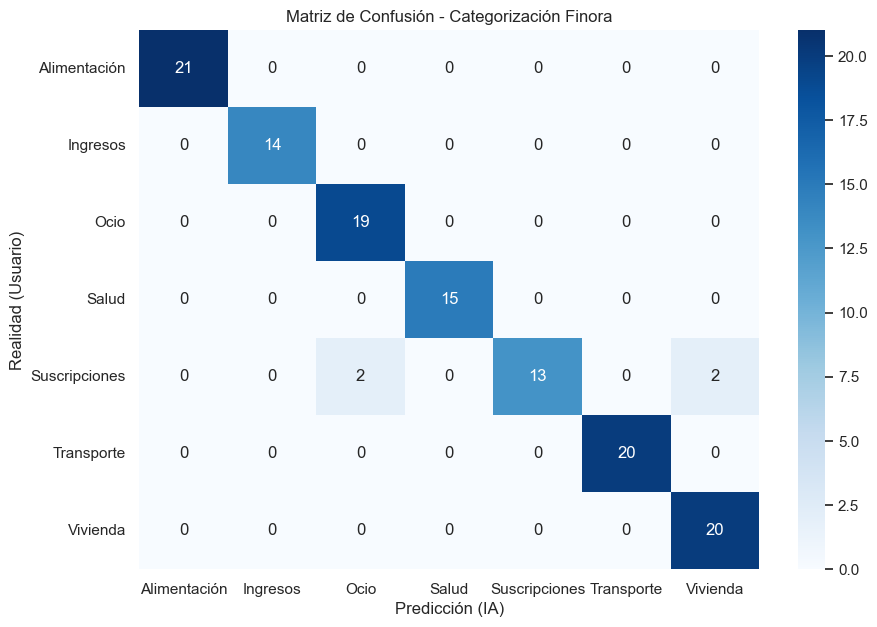

✅ Precisión global del modelo: 96.83%


In [17]:
# ==============================================================================
# EVALUACIÓN DE MÉTRICAS
# ==============================================================================

# 1. Informe de métricas por categoría
report = classification_report(y_test, y_pred)
print("📝 Informe de Clasificación:")
print(report)

# 2. Generación de la Matriz de Confusión
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, 
            yticklabels=model.classes_)

plt.title('Matriz de Confusión - Categorización Finora')
plt.xlabel('Predicción (IA)')
plt.ylabel('Realidad (Usuario)')
plt.show()

# 3. Precisión Global (Accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Precisión global del modelo: {accuracy * 100:.2f}%")

In [18]:
# ==============================================================================
# ANÁLISIS DE ERRORES (nueva celda)
# ==============================================================================

# Ver qué ejemplos se están clasificando mal
errors_df = pd.DataFrame({
    'descriptor': X_test_raw.values,
    'real': y_test.values,
    'predicho': y_pred
})
errors_df = errors_df[errors_df['real'] != errors_df['predicho']]

print(f"❌ Total de errores: {len(errors_df)} de {len(y_test)}")
if len(errors_df) > 0:
    print("\nEjemplos mal clasificados:")
    display(errors_df)

❌ Total de errores: 4 de 126

Ejemplos mal clasificados:


,descriptor,real,predicho
31,patreon monthly,Suscripciones,Ocio
45,patreon monthly,Suscripciones,Ocio
50,cuota gimnasio,Suscripciones,Vivienda
55,cuota gimnasio,Suscripciones,Vivienda


# 🧪 Fase 6: Implementación de la Lógica de Inferencia (RF-14)
Llegamos al punto crítico para cumplir con el requisito [RF-14]. No solo necesitamos que el modelo asigne una categoría, sino que el sistema sea capaz de:

1. Calcular el nivel de confianza: Utilizando las probabilidades internas del modelo.

2. Aplicar el Fallback: Si la confianza es inferior al 50%, la transacción se asignará automáticamente a la categoría "Otros".

3. Procesar en Tiempo Real: Una función que reciba el texto sucio y devuelva el objeto JSON final.

Esta lógica es la que posteriormente se expondrá a través de una API para que el backend en Node.js de Finora pueda consumirla.

In [19]:
# ==============================================================================
# FUNCIÓN DE CATEGORIZACIÓN FINAL CON LÓGICA DE CONFIANZA
# ==============================================================================
from sklearn.calibration import CalibratedClassifierCV

# Si el modelo elegido no tiene predict_proba, lo calibramos
if not hasattr(model, 'predict_proba'):
    print("⚙️  Calibrando modelo para obtener probabilidades...")
    model = CalibratedClassifierCV(model, cv=5)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"✅ Modelo calibrado. Precisión: {accuracy * 100:.2f}%")

def categorize_transaction(raw_descriptor):
    """
    Recibe un descriptor original y devuelve la categoría y el nivel de confianza.
    Implementa el fallback a 'Otros' según RF-14.
    """
    # 1. Limpieza
    cleaned = clean_text(raw_descriptor)

    # 2. Vectorización
    vectorized = tfidf.transform([cleaned])

    # 3. Obtener probabilidades para todas las categorías
    probabilities = model.predict_proba(vectorized)[0]

    # 4. Identificar la categoría con mayor probabilidad
    max_idx = np.argmax(probabilities)
    confidence = probabilities[max_idx]
    category_assigned = model.classes_[max_idx]

    # 5. Lógica de Fallback (RF-14: confianza < 50% -> "Otros")
    if confidence < CONFIDENCE_THRESHOLD:
        final_category = "Otros"
    else:
        final_category = category_assigned

    return {
        "original": raw_descriptor,
        "clean": cleaned,
        "category_predicted": category_assigned,
        "confidence": round(confidence * 100, 2),
        "final_category": final_category,
        "is_fallback": final_category == "Otros" and category_assigned != "Otros"
    }

# ==============================================================================
# PRUEBA DE FUEGO: Transacciones nuevas (no vistas por el modelo)
# ==============================================================================

test_samples = [
    "COMPRA EN ZARA MADRID",           # Debería ser Ocio o Otros
    "NETFLIX.COM DIGITAL",             # Debería ser Suscripciones (alta confianza)
    "PAGO EN FARMACIA DE GUARDIA",     # Debería ser Salud
    "TRANSFERENCIA DE MI PADRE",       # Debería ser Ingresos o Otros
    "REPARACION CALDERA",              # Debería ser Vivienda
    "DESCONOCIDO 12345"                # Debería dar confianza baja -> Otros
]

print(f"{'DESCRIPTOR':<30} | {'PREDICCIÓN':<15} | {'CONFIDENCIA':<12} | {'RESULTADO FINAL'}")
print("-" * 80)

for sample in test_samples:
    res = categorize_transaction(sample)
    print(f"{res['original']:<30} | {res['category_predicted']:<15} | {res['confidence']:>10}% | {res['final_category']}")

⚙️  Calibrando modelo para obtener probabilidades...
✅ Modelo calibrado. Precisión: 96.83%
DESCRIPTOR                     | PREDICCIÓN      | CONFIDENCIA  | RESULTADO FINAL
--------------------------------------------------------------------------------
COMPRA EN ZARA MADRID          | Ocio            |      60.98% | Ocio
NETFLIX.COM DIGITAL            | Suscripciones   |      93.09% | Suscripciones
PAGO EN FARMACIA DE GUARDIA    | Salud           |      89.18% | Salud
TRANSFERENCIA DE MI PADRE      | Ingresos        |      87.59% | Ingresos
REPARACION CALDERA             | Vivienda        |      88.62% | Vivienda
DESCONOCIDO 12345              | Ocio            |      27.49% | Otros


# 💾 Fase 7: Persistencia del Modelo y el Vectorizador
Para que nuestro trabajo no se pierda al cerrar el Notebook y pueda ser utilizado por el backend de Finora en un contenedor Docker, necesitamos "congelar" y guardar los objetos que hemos entrenado.

Es fundamental guardar dos archivos:

1. El Vectorizador (tfidf.joblib): Contiene el "diccionario" y las reglas para convertir texto a números. Sin él, el modelo no entendería las palabras que le enviamos.

2. El Modelo (model.joblib): Es el cerebro de Random Forest con todos los pesos y decisiones ya calculados.

Utilizaremos la librería joblib por su eficiencia al manejar grandes matrices de datos de Scikit-Learn.

In [20]:
# ==============================================================================
# EXPORTACIÓN DE ARTEFACTOS PARA PRODUCCIÓN
# ==============================================================================

# 1. Definir nombres de archivos
MODEL_PATH = "classifier_model.joblib"
VECTORIZER_PATH = "tfidf_vectorizer.joblib"

# 2. Guardar los objetos
print(f"💾 Guardando modelo en: {MODEL_PATH}...")
joblib.dump(model, MODEL_PATH)

print(f"💾 Guardando vectorizador en: {VECTORIZER_PATH}...")
joblib.dump(tfidf, VECTORIZER_PATH)

print("\n✅ Artefactos guardados con éxito.")
print("🚀 Estos archivos son los que deberás copiar a tu carpeta de Docker para el despliegue.")

💾 Guardando modelo en: classifier_model.joblib...
💾 Guardando vectorizador en: tfidf_vectorizer.joblib...

✅ Artefactos guardados con éxito.
🚀 Estos archivos son los que deberás copiar a tu carpeta de Docker para el despliegue.


# 🏁 Conclusión del Desarrollo del Motor IA
Con esto hemos completado el ciclo de vida del RF-14 dentro del entorno de experimentación:

1. Hemos generado y preprocesado datos realistas.

2. Hemos entrenado un modelo capaz de generalizar categorías.

3. Hemos validado que la precisión es adecuada para un TFG.

4. Hemos implementado la lógica de negocio (Fallback a "Otros").

5. Hemos exportado los archivos necesarios para la integración.